# **Combining both strategies: SMA+BB**

**Goal:** Stronger signals/Identify weak signals
> **Unanimous signal:**
>1. Pro: Strong Signal
>2. Con: Doesn't work with too many indicators
>* Buy if all signals indicate buy
>* Sell if all signals indicate sell
>* Stay neutral if signals are Non unanimous

>**Majority/Tendency:**
>1. Pro: Can be customized
>2. Con: More trades/Weak signals
>* Buy if atleast [70-80%] of all signals are indicating buy
>* Buy if [>50%] signals are indicating buy and [<25%] signals are indicating sell
>* Sell if [>50%] signals are indicating sell and [<25%] signals are indicating buy  

To combine both the strategies, we need to combine returns and positions of both strategies

In [127]:
import sys
import os
import numpy as np
import pandas as pd
import yfinance as yf
import datetime as dt
import matplotlib.pyplot as plt
from itertools import product

['L330-332 Intro and SMA+BB.ipynb', 'L333-3334 Combining SMA+BB and busy hours.ipynb', 'SMA_and_BB.py', 'SMA_plus_BB.py']


In [128]:
class SMABackTester():      # Creating a class
  def __init__(self,company_symbol,period,interval,SMA_S,SMA_L):
    self.company_symbol=company_symbol
    self.period=period
    self.interval=interval
    self.SMA_S=SMA_S
    self.SMA_L=SMA_L
    self.result={}
    self.get_data()
    self.calculate_data()

  # Method: get_data()
  def get_data(self):
    stock=yf.download(tickers=self.company_symbol,period=self.period,interval= self.interval,auto_adjust=True)
    self.df=pd.DataFrame(stock["Close"])

  # Method: calculate_date():
  def calculate_data(self):
    for symbol in self.company_symbol:
      self.df[f"LR {symbol}"]=np.log(self.df[symbol]/self.df[symbol].shift(1))
      self.df[f"SMA_L {symbol}"]=self.df[symbol].rolling(window=self.SMA_L).mean()
      self.df[f"SMA_S {symbol}"]=self.df[symbol].rolling(window=self.SMA_S).mean()
      self.df.dropna(inplace=True)
      self.result[symbol] = self.df
    return self.df.dropna()

  # Method: set_parameters():Will be used for multiple combination of SMA_S & SMA_L
  def set_SMA_SnL(self,SMA_S=None,SMA_L=None):
    if self.SMA_S is not None:
      self.SMA_S=SMA_S
    if self.SMA_L is not None:
      self.SMA_L=SMA_L
    self.calculate_data()

  # Method: test_strategy(): will test the position and strategy for all SMA_S & SMA_L combination.
  def test_strategy(self):
    for symbol in self.company_symbol:
      self.df[f"Position {symbol}"]=np.where(self.df[f"SMA_S {symbol}"]>self.df[f"SMA_L {symbol}"],1,-1)
      self.df[f"Strategy {symbol}"]=self.df[f"Position {symbol}"].shift(1)*self.df[f"LR {symbol}"]
      self.df.dropna(inplace=True)
      self.df[f"Cumulative Return {symbol}"]=np.exp(self.df[f"LR {symbol}"].cumsum())
      self.df[f"Cumulative Strategy {symbol}"]=np.exp(self.df[f"Strategy {symbol}"].cumsum())
    return self.df.dropna()

  # Method: plot_result(): Will plot the results of the strategy for every ticker symbol
  def plot_result(self,ticker=None):
    if ticker is None:
      to_plot=self.company_symbol
    elif isinstance(ticker,str):
      to_plot=[ticker]
    else:
      to_plot=ticker
    for symbol in to_plot:
      if self.df[symbol] is None:
        print(f"Run the test_strategy() for {symbol} 1st!")
      else:
        fig,(ax1,ax2)=plt.subplots(2,1,figsize=(12,8),sharex=True)
        ax1.plot(self.df.index, self.df[symbol], label="Price", alpha=0.5)
        ax1.plot(self.df.index, self.df[f"SMA_S {symbol}"], label=f"SMA_S ({self.SMA_S})", color="orange")
        ax1.plot(self.df.index, self.df[f"SMA_L {symbol}"], label=f"SMA_L ({self.SMA_L})", color="blue")
        ax1.set_title(f"{symbol} - SMA Crossover")
        ax1.set_ylabel("Price")
        ax1.legend()
        ax2.plot(self.df.index, self.df[f"Cumulative Strategy {symbol}"], label="Strategy Performance", color="green")
        ax2.plot(self.df.index, self.df[f"Cumulative Return {symbol}"], label="Buy & Hold", color="gray", linestyle="--")
        ax2.set_ylabel("Growth ($1 Invested)")
        ax2.legend()
        plt.show()

  # Method: optimize_para(): make combination of SMA_S & SMA_L for different strategy output check
  def optimize_para(self,SMA_S_range,SMA_L_range):
    # making the combinations
    combination=list(product(range(*SMA_S_range),range(*SMA_L_range)))
    performance=[]
    for comb in combination:
      s,l=comb
      if s>l:
        continue
      self.set_parameters(s,l)
      # Access the result for the first company symbol and get the last 'Cumulative Strategy' value
      # Assuming optimization is based on the first company in the list
      df_first_company_result = self.test_strategy()[self.company_symbol[0]]
      performance.append(df_first_company_result["Cumulative Strategy"].iloc[-1])
    best_perf=np.max(performance)    # find best score
    opt=combination[np.argmax(performance)]    # find the SMA_S & SMA_L which gave the best score
    # Testing the best strategy by using optimal parameter (SMA_S & SMA_L)
    self.set_parameters(opt[0],opt[1])
    self.test_strategy()
    return self.performance

class BolingerBands():
  def __init__(self, company,period,interval):
    self.company=company
    self.period=period
    self.interval=interval
    self.get_data()

  def get_data(self):
    data=yf.download(self.company,period=self.period,interval=self.interval,auto_adjust=True)
    self.df=pd.DataFrame(data["Close"])
    return self.df

  def calculate_data(self):
    SMA=7;deviation=2;ptc=0.00007
    for ticker in self.company:
      self.df[f"LR {ticker}"]=np.log(self.df[ticker]/self.df[ticker].shift(1))
      self.df[f"SMA {ticker}"]=self.df[ticker].rolling(SMA).mean()
      # Corrected Bollinger Band calculation:
      self.df[f"Lower {ticker}"]=self.df[f"SMA {ticker}"] - (self.df[ticker].rolling(SMA).std()*deviation)
      self.df[f"Upper {ticker}"]=self.df[f"SMA {ticker}"] + (self.df[ticker].rolling(SMA).std()*deviation)
      self.df[f"Distance {ticker}"]=self.df[ticker]-self.df[f"SMA {ticker}"]
      conditions = [self.df[ticker] < self.df[f"Lower {ticker}"], # Buy if price is below the lower band
          self.df[ticker] > self.df[f"Upper {ticker}"] ] # Sell if price is above the upper band
      choices = [1, -1] # Corresponding choices for the conditions
      self.df[f"Position {ticker}"] = np.select(conditions, choices, default=0) # Default to 0 (neutral) if no conditions met

      self.df[f"Strategy {ticker}"]=self.df[f"Position {ticker}"].shift(1)*self.df[f"LR {ticker}"]
      self.df[f"Cumulative Return {ticker}"]=np.exp(self.df[f"LR {ticker}"].cumsum())
      self.df[f"Cumulative Strategy {ticker}"]=np.exp(self.df[f"Strategy {ticker}"].cumsum())
      self.df[f"Trades {ticker}"]=self.df[f"Position {ticker}"].diff().fillna(0).abs()
      self.df[f"Net_Strategy {ticker}"]=self.df[f"Strategy {ticker}"]-self.df[f"Trades {ticker}"]*ptc
      self.df[f"Cumulative Net_Strategy {ticker}"]=np.exp(self.df[f"Net_Strategy {ticker}"].cumsum())
    return self.df.dropna()

  def plot_data(self):
    for ticker in self.company:
      self.df[[f"{ticker}",f"SMA {ticker}",f"Lower {ticker}",f"Upper {ticker}"]].plot(figsize=(15,6),fontsize=12)
      plt.legend(fontsize=12)
      plt.show()
      self.df[[f"Cumulative Return {ticker}",f"Cumulative Strategy {ticker}"]].plot(figsize=(15,6),fontsize=12,title=f"Cumulative Result of {ticker}")
      plt.legend(fontsize=12)
      plt.show()
      self.df[[f"Cumulative Strategy {ticker}",f"Cumulative Net_Strategy {ticker}"]].plot(figsize=(15,6),fontsize=12,title=f"Cumulative Result of {ticker}")
      plt.legend(fontsize=12)
      plt.show()

  def ann_result(self):
    ann_return=[];ann_risk=[]
    for ticker in self.company:
      ann_return.append(self.df[[f"LR {ticker}",f"Net_Strategy {ticker}"]].mean()*(4*252))
      ann_risk.append(self.df[[f"LR {ticker}",f"Net_Strategy {ticker}"]].std()*np.sqrt(4*252))
    print(f"Annual Returns of companies = {ann_return}")
    print(f"Annual Risks of companies = {ann_risk}")

In [129]:
symbol=["HAL.NS"];period="8d";timeframe="1m"
data1=SMABackTester(company_symbol=symbol,period=period,interval=timeframe,SMA_L=30,SMA_S=7)
data1.calculate_data();data1.test_strategy()

[*********************100%***********************]  1 of 1 completed


Ticker,HAL.NS,LR HAL.NS,SMA_L HAL.NS,SMA_S HAL.NS,Position HAL.NS,Strategy HAL.NS,Cumulative Return HAL.NS,Cumulative Strategy HAL.NS
Datetime,,,,,,,,
2026-02-06 04:44:00+00:00,3987.000000,0.000075,3999.846688,3990.042864,-1,-0.000075,1.000075,0.999925
2026-02-06 04:45:00+00:00,3987.600098,0.000151,3999.156689,3989.014300,-1,-0.000151,1.000226,0.999774
2026-02-06 04:46:00+00:00,3987.000000,-0.000151,3998.256689,3988.157157,-1,0.000151,1.000075,0.999925
2026-02-06 04:47:00+00:00,3992.000000,0.001253,3997.556689,3988.442871,-1,-0.001253,1.001329,0.998672
2026-02-06 04:48:00+00:00,3996.699951,0.001177,3996.980021,3989.828578,-1,-0.001177,1.002508,0.997498
...,...,...,...,...,...,...,...,...
2026-02-17 09:55:00+00:00,4240.000000,-0.000707,4248.546631,4243.928571,-1,0.000707,1.063536,0.953993
2026-02-17 09:56:00+00:00,4240.500000,0.000118,4248.423291,4243.271415,-1,-0.000118,1.063662,0.953880
2026-02-17 09:57:00+00:00,4240.200195,-0.000071,4248.353304,4242.371443,-1,0.000071,1.063586,0.953948


In [130]:
data1.df["Position HAL.NS"].value_counts()    # check the number of position changes in the strategy

,count
Position HAL.NS,
1,1535
-1,1390


In [131]:
data2=BolingerBands(company=symbol,period=period,interval=timeframe)
data2.calculate_data()

[*********************100%***********************]  1 of 1 completed


Ticker,HAL.NS,LR HAL.NS,SMA HAL.NS,Lower HAL.NS,Upper HAL.NS,Distance HAL.NS,Position HAL.NS,Strategy HAL.NS,Cumulative Return HAL.NS,Cumulative Strategy HAL.NS,Trades HAL.NS,Net_Strategy HAL.NS,Cumulative Net_Strategy HAL.NS
Datetime,,,,,,,,,,,,,
2026-02-06 03:51:00+00:00,4048.000000,0.000000,4042.500000,4023.619335,4061.380665,5.500000,0,0.0,1.003844,1.000000,0.0,0.0,1.000000
2026-02-06 03:52:00+00:00,4043.500000,-0.001112,4044.071429,4027.369462,4060.773395,-0.571429,0,-0.0,1.002728,1.000000,0.0,-0.0,1.000000
2026-02-06 03:53:00+00:00,4038.000000,-0.001361,4045.057129,4031.388695,4058.725563,-7.057129,0,-0.0,1.001364,1.000000,0.0,-0.0,1.000000
2026-02-06 03:54:00+00:00,4033.000000,-0.001239,4044.785714,4030.135832,4059.435596,-11.785714,0,-0.0,1.000124,1.000000,0.0,-0.0,1.000000
2026-02-06 03:55:00+00:00,4028.199951,-0.001191,4041.957136,4023.147945,4060.766327,-13.757185,0,-0.0,0.998934,1.000000,0.0,-0.0,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-17 09:55:00+00:00,4240.000000,-0.000707,4243.928571,4239.810763,4248.046380,-3.928571,0,-0.0,1.051457,1.012569,0.0,-0.0,0.999891
2026-02-17 09:56:00+00:00,4240.500000,0.000118,4243.271415,4238.595650,4247.947179,-2.771415,0,0.0,1.051581,1.012569,0.0,0.0,0.999891
2026-02-17 09:57:00+00:00,4240.200195,-0.000071,4242.371443,4238.197464,4246.545421,-2.171247,0,-0.0,1.051507,1.012569,0.0,-0.0,0.999891


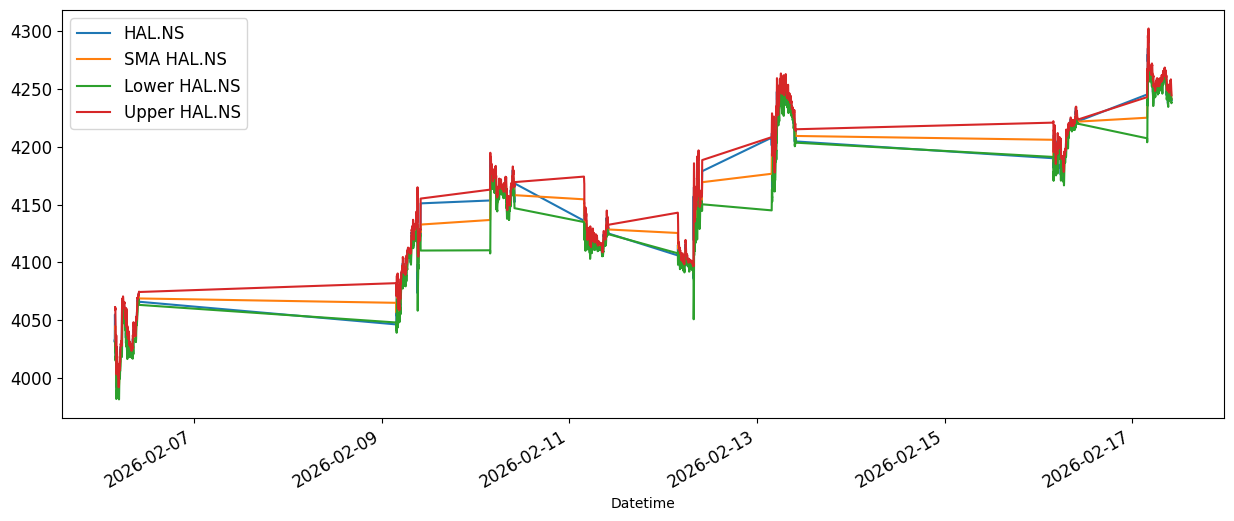

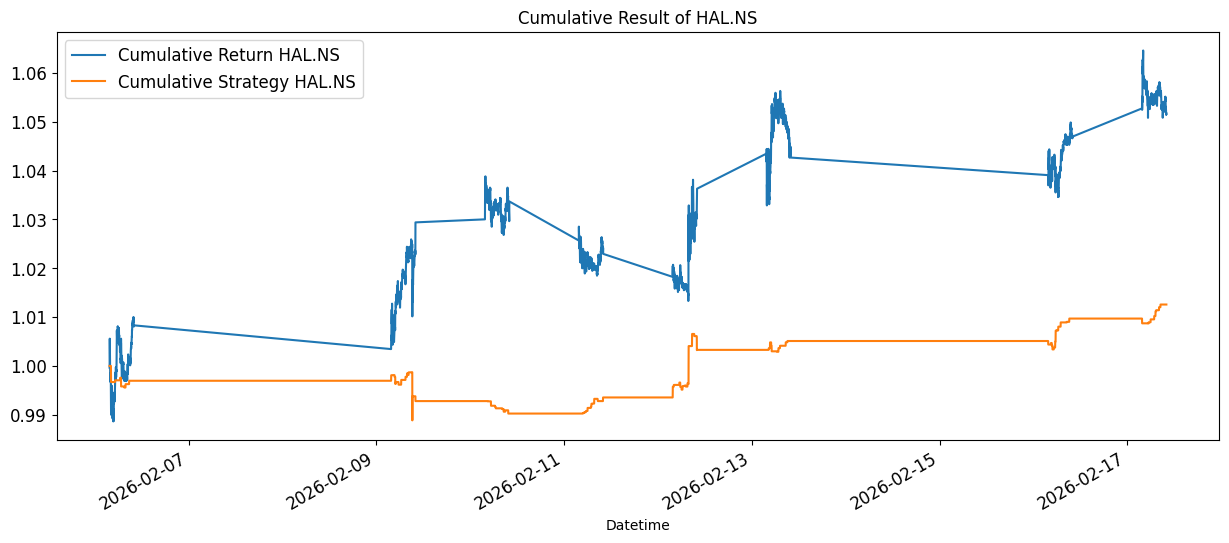

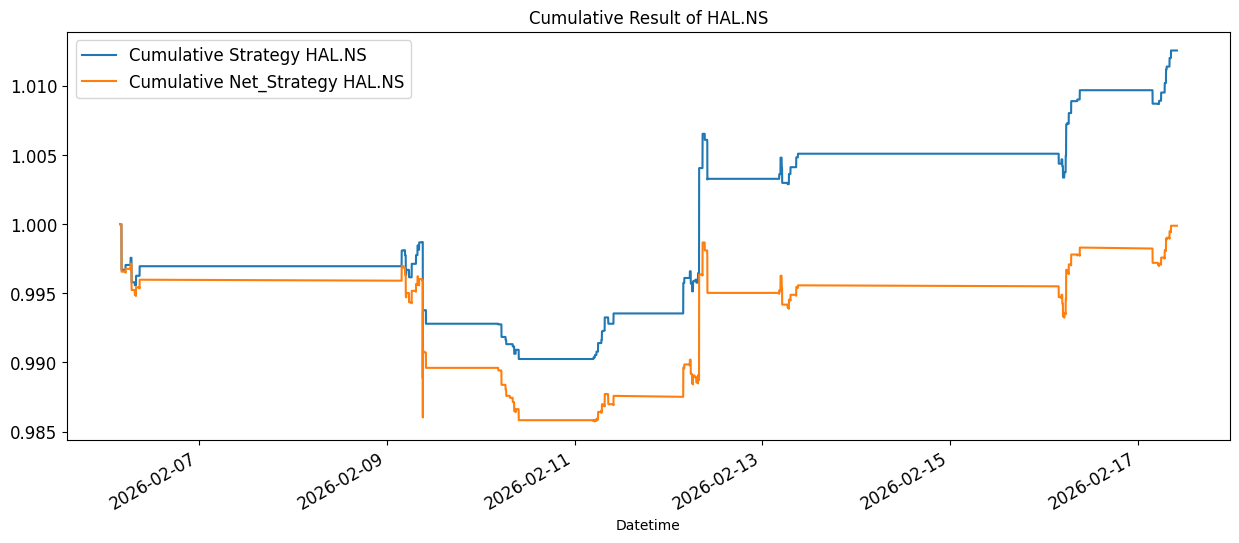

In [132]:
data2.df["Position HAL.NS"].value_counts()    # check the number of trades in strategy
data2.plot_data()

In [133]:
comb=data1.df.loc[:,["LR HAL.NS","Position HAL.NS"]]
comb.rename(columns={"Position HAL.NS":"Position SMA"},inplace=True)
comb["Position BB"]=data2.df['Position HAL.NS']
comb

Ticker,LR HAL.NS,Position SMA,Position BB
Datetime,,,
2026-02-06 04:44:00+00:00,0.000075,-1,0
2026-02-06 04:45:00+00:00,0.000151,-1,0
2026-02-06 04:46:00+00:00,-0.000151,-1,0
2026-02-06 04:47:00+00:00,0.001253,-1,0
2026-02-06 04:48:00+00:00,0.001177,-1,0
...,...,...,...
2026-02-17 09:55:00+00:00,-0.000707,-1,0
2026-02-17 09:56:00+00:00,0.000118,-1,0
2026-02-17 09:57:00+00:00,-0.000071,-1,0


**Check if both agrees than buy/sell**

In [134]:
comb["Position Combine"]=np.where(comb['Position BB']==comb['Position SMA'],comb['Position BB'],0)
comb['Position Combine'].value_counts()

,count
Position Combine,
0,2889
-1,21
1,15


# **Taking into account busy trading hours**

In [136]:
comb["IST"]=comb.index.tz_convert("Asia/Kolkata")
comb["Hour"]=comb["IST"].dt.hour
comb["Hour"].value_counts()

,count
Hour,
11,480
14,480
13,480
10,466
12,464
9,315
15,240


In [141]:
comb['Position Combine']=np.where(comb['Hour'].between(10,14),comb["Position Combine"],0)   # 10 to 14 is busy trading hour (more values are in these hours)
comb['Position Combine'].value_counts()

,count
Position Combine,
0,2902
-1,12
1,11


<Axes: xlabel='Datetime'>

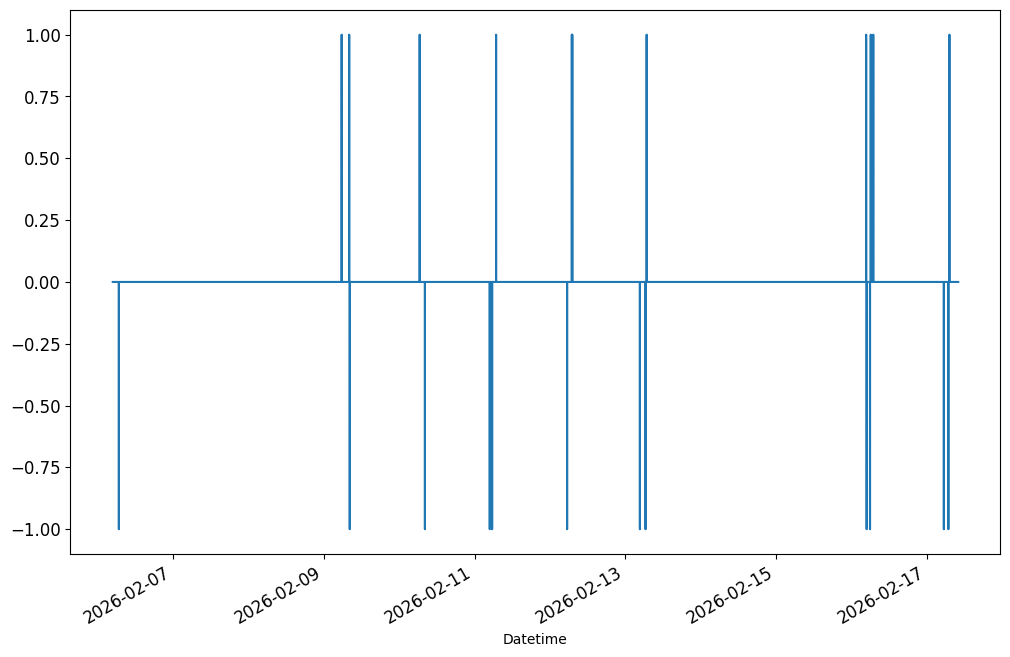

In [142]:
comb['Position Combine'].plot(figsize=(12,8),fontsize=12)